# Recovery-over-time distribution

This notebook uses the cached 5000-scenario performance evaluations to plot the percentage of scenarios whose controllable-bus voltages have recovered to the safe range over control steps. It does not rerun power-flow simulations.

For methods with scenarios that reached the 200-step evaluation horizon without recovery, those scenarios are kept as unrecovered and therefore are not counted as recovered at the horizon. This is slightly more conservative than treating the capped value as an actual recovery time.


In [1]:
from pathlib import Path
import gzip
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import Config

CACHE_DIR = Path(Config.data_path) / 'cache' / 'notebook_results'
OUTPUT_DIR = Path(Config.data_path) / 'images' / 'recovery_over_time_distribution'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 200
N_SCENARIOS = 5000

METHODS = [
    'Linear',
    'Safe-DDPG',
    'RLC-FT (fixed topology)',
    'RLC-FT',
]
COLORS = {
    'Linear': '#BDBDBD',
    'Safe-DDPG': '#5B8DB8',
    'RLC-FT (fixed topology)': '#D95F02',
    'RLC-FT': '#1B9E77',
}
LINESTYLES = {
    'Linear': '-',
    'Safe-DDPG': '-',
    'RLC-FT (fixed topology)': '-',
    'RLC-FT': '-',
}

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


def load_cache(name):
    path = CACHE_DIR / f'{name}.pkl.gz'
    if not path.exists():
        raise FileNotFoundError(path)
    with gzip.open(path, 'rb') as f:
        payload = pickle.load(f)
    return payload.get('data', payload)


def recovery_from_success_list(success_list, n=N_SCENARIOS, horizon=HORIZON):
    """Return recovery times and actual recovery mask indexed by scenario id."""
    times = np.full(n, horizon, dtype=float)
    recovered = np.zeros(n, dtype=bool)
    arr = np.asarray(success_list)
    if arr.size == 0:
        return times, recovered
    arr = arr.reshape(-1, 2)
    episode_ids = arr[:, 0].astype(int)
    recovery_steps = arr[:, 1].astype(float)
    valid = (episode_ids >= 0) & (episode_ids < n)
    times[episode_ids[valid]] = recovery_steps[valid]
    recovered[episode_ids[valid]] = True
    return times, recovered


def recovery_curve(times, recovered, horizon=HORIZON):
    steps = np.arange(horizon + 1)
    recovered_percent = []
    for t in steps:
        recovered_by_t = recovered & (times <= t)
        recovered_percent.append(100.0 * recovered_by_t.mean())
    recovered_percent = np.asarray(recovered_percent)
    unrecovered_percent = 100.0 - recovered_percent
    return steps, recovered_percent, unrecovered_percent


def build_system_data(system):
    if system == '56bus':
        cache_names = {
            'Linear': '56bus_linear',
            'Safe-DDPG': '56bus_safe_ddpg',
            'RLC-FT (fixed topology)': '56bus_rlcft_fixed_topology',
            'RLC-FT': '56bus_rlcft',
        }
        success_keys = {
            'Linear': 'base_succ_list',
            'Safe-DDPG': 'safe_succ_list',
            'RLC-FT (fixed topology)': 'success_list_',
            'RLC-FT': 'success_list',
        }
    elif system == '123bus':
        cache_names = {
            'Linear': '123bus_linear_metrics',
            'Safe-DDPG': '123bus_safe_ddpg_metrics',
            'RLC-FT (fixed topology)': '123bus_rlcft_fixed_topology_metrics',
            'RLC-FT': '123bus_rlcft_metrics',
        }
        success_keys = {
            'Linear': 'base_succ_list',
            'Safe-DDPG': 'safe_succ_list',
            'RLC-FT (fixed topology)': 'success_list_',
            'RLC-FT': 'success_list',
        }
    else:
        raise ValueError(system)

    rows = []
    curves = {}
    for method in METHODS:
        data = load_cache(cache_names[method])
        times, recovered = recovery_from_success_list(data[success_keys[method]])
        steps, rec, unrec = recovery_curve(times, recovered)
        curves[method] = {
            'steps': steps,
            'recovered_percent': rec,
            'unrecovered_percent': unrec,
            'times': times,
            'recovered': recovered,
        }
        rows.append({
            'system': system,
            'method': method,
            'n': len(times),
            'recovered_within_horizon': int(recovered.sum()),
            'horizon_reached': int((~recovered).sum()),
            'median_recovery_time': float(np.median(times)),
            'q75_recovery_time': float(np.quantile(times, 0.75)),
            'q90_recovery_time': float(np.quantile(times, 0.90)),
            'q95_recovery_time': float(np.quantile(times, 0.95)),
            'recovered_at_20_steps_percent': float(rec[20]),
            'recovered_at_50_steps_percent': float(rec[50]),
            'recovered_at_100_steps_percent': float(rec[100]),
            'recovered_at_200_steps_percent': float(rec[200]),
            'unrecovered_at_20_steps_percent': float(unrec[20]),
            'unrecovered_at_50_steps_percent': float(unrec[50]),
            'unrecovered_at_100_steps_percent': float(unrec[100]),
            'unrecovered_at_200_steps_percent': float(unrec[200]),
        })
    return curves, pd.DataFrame(rows)

curves_56, summary_56 = build_system_data('56bus')
curves_123, summary_123 = build_system_data('123bus')
summary = pd.concat([summary_56, summary_123], ignore_index=True)
summary_path = OUTPUT_DIR / 'recovery_over_time_distribution_summary.csv'
summary.to_csv(summary_path, index=False)
print('Saved summary:', summary_path)
summary


Saved summary: D:\Code\Python\Flexible_Voltage_Control\images\recovery_over_time_distribution\recovery_over_time_distribution_summary.csv


,system,method,n,recovered_within_horizon,horizon_reached,median_recovery_time,q75_recovery_time,q90_recovery_time,q95_recovery_time,recovered_at_20_steps_percent,recovered_at_50_steps_percent,recovered_at_100_steps_percent,recovered_at_200_steps_percent,unrecovered_at_20_steps_percent,unrecovered_at_50_steps_percent,unrecovered_at_100_steps_percent,unrecovered_at_200_steps_percent
0,56bus,Linear,5000,5000,0,30.0,55.0,83.1,99.0,36.84,71.30,95.24,100.00,63.16,28.70,4.76,0.00
1,56bus,Safe-DDPG,5000,5000,0,16.0,36.0,58.0,69.0,56.42,86.20,100.00,100.00,43.58,13.80,0.00,0.00
2,56bus,RLC-FT (fixed topology),5000,5000,0,8.0,14.0,26.0,35.0,85.14,99.24,100.00,100.00,14.86,0.76,0.00,0.00
3,56bus,RLC-FT,5000,5000,0,5.0,10.0,19.0,25.0,91.68,99.98,100.00,100.00,8.32,0.02,0.00,0.00
4,123bus,Linear,5000,4543,457,108.0,147.0,195.0,200.0,0.30,9.28,44.34,90.86,99.70,90.72,55.66,9.14
5,123bus,Safe-DDPG,5000,4505,495,51.0,77.0,139.0,200.0,7.78,49.28,85.18,90.10,92.22,50.72,14.82,9.90
6,123bus,RLC-FT (fixed topology),5000,5000,0,19.0,32.0,46.0,56.0,53.28,92.88,99.98,100.00,46.72,7.12,0.02,0.00
7,123bus,RLC-FT,5000,5000,0,15.0,25.0,36.0,43.0,66.02,97.54,100.00,100.00,33.98,2.46,0.00,0.00


In [2]:
# Save curve data in long format for checking and reuse.
curve_rows = []
for system, curves in [('56bus', curves_56), ('123bus', curves_123)]:
    for method, info in curves.items():
        for step, recovered_value, unrecovered_value in zip(
            info['steps'], info['recovered_percent'], info['unrecovered_percent']
        ):
            curve_rows.append({
                'system': system,
                'method': method,
                'step': int(step),
                'recovered_percent': float(recovered_value),
                'unrecovered_percent': float(unrecovered_value),
            })
curve_df = pd.DataFrame(curve_rows)
curve_path = OUTPUT_DIR / 'recovery_over_time_distribution_curves.csv'
curve_df.to_csv(curve_path, index=False)
print('Saved curves:', curve_path)
curve_df.head()


Saved curves: D:\Code\Python\Flexible_Voltage_Control\images\recovery_over_time_distribution\recovery_over_time_distribution_curves.csv


,system,method,step,recovered_percent,unrecovered_percent
0,56bus,Linear,0,1.92,98.08
1,56bus,Linear,1,1.96,98.04
2,56bus,Linear,2,2.08,97.92
3,56bus,Linear,3,2.14,97.86
4,56bus,Linear,4,2.42,97.58


Saved: D:\Code\Python\Flexible_Voltage_Control\images\recovery_over_time_distribution\recovery_over_time_distribution_56_123.png
Saved: D:\Code\Python\Flexible_Voltage_Control\images\recovery_over_time_distribution\recovery_over_time_distribution_56_123.pdf


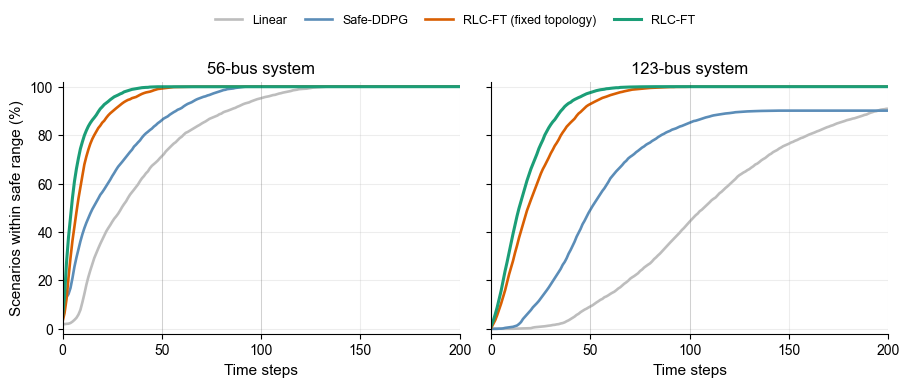

In [3]:
def plot_recovery_distribution(curves_by_system, output_stem):
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.6), sharey=True)
    system_titles = {'56bus': '56-bus system', '123bus': '123-bus system'}
    for ax, (system, curves) in zip(axes, curves_by_system.items()):
        for method in METHODS:
            info = curves[method]
            ax.plot(
                info['steps'],
                info['recovered_percent'],
                color=COLORS[method],
                linestyle=LINESTYLES[method],
                linewidth=2.2 if method == 'RLC-FT' else 1.9,
                label=method,
            )
        ax.set_title(system_titles[system])
        ax.set_xlabel('Time steps')
        ax.set_xlim(0, HORIZON)
        ax.set_ylim(-2, 102)
        ax.set_xticks([0, 50, 100, 150, 200])
        ax.grid(True, axis='both', alpha=0.22, linewidth=0.8)
        ax.spines[['top', 'right']].set_visible(False)
        for x in [50, 100, 200]:
            ax.axvline(x, color='black', linewidth=0.7, alpha=0.12)
    axes[0].set_ylabel('Scenarios within safe range (%)')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08),
        ncol=4,
        frameon=False,
        columnspacing=1.4,
        handlelength=2.2,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    png_path = OUTPUT_DIR / f'{output_stem}.png'
    pdf_path = OUTPUT_DIR / f'{output_stem}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print('Saved:', png_path)
    print('Saved:', pdf_path)
    return fig

fig = plot_recovery_distribution(
    {'56bus': curves_56, '123bus': curves_123},
    'recovery_over_time_distribution_56_123',
)
plt.show()


In [4]:
# Compact selected-time table for quick inspection.
selected = summary[[
    'system', 'method', 'median_recovery_time', 'q90_recovery_time', 'q95_recovery_time',
    'recovered_at_20_steps_percent', 'recovered_at_50_steps_percent',
    'recovered_at_100_steps_percent', 'recovered_at_200_steps_percent',
    'horizon_reached',
]].copy()
selected


,system,method,median_recovery_time,q90_recovery_time,q95_recovery_time,recovered_at_20_steps_percent,recovered_at_50_steps_percent,recovered_at_100_steps_percent,recovered_at_200_steps_percent,horizon_reached
0,56bus,Linear,30.0,83.1,99.0,36.84,71.30,95.24,100.00,0
1,56bus,Safe-DDPG,16.0,58.0,69.0,56.42,86.20,100.00,100.00,0
2,56bus,RLC-FT (fixed topology),8.0,26.0,35.0,85.14,99.24,100.00,100.00,0
3,56bus,RLC-FT,5.0,19.0,25.0,91.68,99.98,100.00,100.00,0
4,123bus,Linear,108.0,195.0,200.0,0.30,9.28,44.34,90.86,457
5,123bus,Safe-DDPG,51.0,139.0,200.0,7.78,49.28,85.18,90.10,495
6,123bus,RLC-FT (fixed topology),19.0,46.0,56.0,53.28,92.88,99.98,100.00,0
7,123bus,RLC-FT,15.0,36.0,43.0,66.02,97.54,100.00,100.00,0


In [5]:
# Paper figure: comparison with external baselines only, plotted as recovered scenarios over time.
# The original four-method plotting cell above is retained for reference.
from pathlib import Path
import gzip
import pickle

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from config import Config

PAPER_METHODS = ["Linear", "Safe-DDPG", "RLC-FT"]
PAPER_COLORS = {
    "Linear": "#BDBDBD",
    "Safe-DDPG": "#5B8DB8",
    "RLC-FT": "#1B9E77",
}
HORIZON = 200
N_SCENARIOS = 5000
CACHE_DIR = Path(Config.data_path) / "cache" / "notebook_results"
OUTPUT_DIR = Path(Config.data_path) / "images" / "recovery_over_time_distribution"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _paper_load_cache(name):
    with gzip.open(CACHE_DIR / f"{name}.pkl.gz", "rb") as handle:
        payload = pickle.load(handle)
    return payload.get("data", payload)


def _paper_recovery_data(success_list):
    times = np.full(N_SCENARIOS, HORIZON, dtype=float)
    recovered = np.zeros(N_SCENARIOS, dtype=bool)
    arr = np.asarray(success_list).reshape(-1, 2)
    episode_ids = arr[:, 0].astype(int)
    valid = (episode_ids >= 0) & (episode_ids < N_SCENARIOS)
    times[episode_ids[valid]] = arr[:, 1].astype(float)[valid]
    recovered[episode_ids[valid]] = True
    steps = np.arange(HORIZON + 1)
    recovered_percent = np.asarray([
        100.0 * np.mean(recovered & (times <= step))
        for step in steps
    ])
    return steps, recovered_percent


def _paper_system_curves(system):
    if system == "56bus":
        specs = {
            "Linear": ("56bus_linear", "base_succ_list"),
            "Safe-DDPG": ("56bus_safe_ddpg", "safe_succ_list"),
            "RLC-FT": ("56bus_rlcft", "success_list"),
        }
    else:
        specs = {
            "Linear": ("123bus_linear_metrics", "base_succ_list"),
            "Safe-DDPG": ("123bus_safe_ddpg_metrics", "safe_succ_list"),
            "RLC-FT": ("123bus_rlcft_metrics", "success_list"),
        }
    return {
        method: _paper_recovery_data(_paper_load_cache(cache_name)[success_key])
        for method, (cache_name, success_key) in specs.items()
    }


plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "text.color": "black",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.6), sharey=True)
for ax, system, title, panel in zip(
    axes,
    ["56bus", "123bus"],
    ["56-bus system", "123-bus system"],
    ["a", "b"],
):
    curves = _paper_system_curves(system)
    for method in PAPER_METHODS:
        steps, recovered_percent = curves[method]
        ax.plot(
            steps,
            recovered_percent,
            color=PAPER_COLORS[method],
            linewidth=2.3 if method == "RLC-FT" else 2.0,
            label=method,
        )
    ax.set_title(title)
    ax.text(
        -0.08,
        1.08,
        panel,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax.set_xlabel("Control steps")
    ax.set_xlim(0, HORIZON)
    ax.set_ylim(-2, 102)
    ax.set_xticks([0, 50, 100, 150, 200])
    ax.grid(True, alpha=0.22, linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Scenarios within safe range (%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=3,
    frameon=False,
    columnspacing=1.8,
    handlelength=2.4,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
output_stem = OUTPUT_DIR / "recovery_over_time_distribution_56_123"
fig.savefig(output_stem.with_suffix(".png"), dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
fig.savefig(output_stem.with_suffix(".pdf"), bbox_inches="tight", facecolor="white", transparent=False)
print(f"Saved paper recovery figure to {output_stem.with_suffix('.pdf')}")
plt.show()


Saved paper recovery figure to D:\Code\Python\Flexible_Voltage_Control\images\recovery_over_time_distribution\recovery_over_time_distribution_56_123.pdf


C:\Users\wdyao\AppData\Local\Temp\ipykernel_39588\1699582794.py:133: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
